<h1 style="background-color:lightblue; color:white; padding:10px; text-align:center;">
    LangChain implementation with Round Robin 
</h1>

In [2]:
import os
from dotenv import load_dotenv


# Load environment variables
load_dotenv()

False

In [3]:
# !pip install langchain
# !pip install langchain-community


In [4]:
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)

In [5]:
from langchain.chains import LLMChain
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)
from langchain.memory import ConversationBufferMemory
class Agent:
    def __init__(self, name, system_prompt, llm):
        self.name = name
        self.llm = llm
        self.system_prompt = system_prompt
        self.chat_prompt = ChatPromptTemplate.from_messages([
            SystemMessagePromptTemplate.from_template(self.system_prompt),
            HumanMessagePromptTemplate.from_template("{conversation_history}\n{input}")
        ])
        self.chain = LLMChain(
            llm=self.llm,
            prompt=self.chat_prompt,
            verbose=False
        )

    def respond(self, input_text, conversation_history):
        response = self.chain.predict(
            input=input_text,
            conversation_history=conversation_history
        )
        return response


In [6]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    openai_api_key=os.getenv("OPENAI_API_KEY"))

C:\Users\HP\AppData\Local\Temp\ipykernel_14480\1446886985.py:1: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(


In [7]:
# Define Fitness and Nutrition Tracking Agents

# Customer Proxy Agent
customer_proxy_agent = Agent(
    name="Customer_Proxy",
    system_prompt="You are the Customer Proxy Agent. Your primary responsibility is to convey customer requirements to the Project Manager for seamless execution.",
    llm=llm
)

# Project Manager Agent
project_manager_agent = Agent(
    name="Project_Manager",
    system_prompt="You are the Project Manager Agent. Your task is to receive customer requirements and formulate a structured project plan by coordinating outputs from various engineers.",
    llm=llm
)

# Requirement Engineer Agent
requirement_engineer_agent = Agent(
    name="Requirement_Engineer",
    system_prompt=(
        "You are the Requirement Engineer Agent. Your role is to compile a detailed requirements document based on the customer's needs for the fitness monitoring and dietary planning application."
        "\n\nWork collaboratively with the Fitness Agent, Dietetic Agent, and Data Acquisition Agent to collect domain-specific requirements:"
        "\n- The Fitness Agent gathers details on workout objectives, preferred exercise routines, and tracking methodologies."
        "\n- The Dietetic Agent collects dietary habits, target calorie intake, and meal planning preferences."
        "\n- The Data Acquisition Agent gathers user profile information such as age, weight, height, and activity level to enable personalized recommendations."
        "\n\nEstimate the effort needed to complete the requirements document:"
        "\n- Step 1: Determine the total number of requirements gathered from all agents."
        "\n- Step 2: Assume a productivity rate of 5 requirements documented per day."
        "\n- Step 3: Calculate the total effort as: Effort = Total Requirements / Productivity Rate."
    ),
    llm=llm
)

# Fitness Agent
fitness_agent = Agent(
    name="Fitness_Agent",
    system_prompt="You are the Fitness Agent. Your duty is to collect user-specific fitness requirements, including preferred types of exercises (cardio, strength training), workout frequency, and performance tracking mechanisms.",
    llm=llm
)

# Dietetic Agent
dietetic_agent = Agent(
    name="Dietetic_Agent",
    system_prompt="You are the Dietetic Agent. Gather information regarding users' dietary preferences, daily calorie targets, and meal planning options to ensure personalized nutrition tracking.",
    llm=llm
)

# Data Acquisition Agent
data_acquisition_agent = Agent(
    name="Data_Acquisition_Agent",
    system_prompt="You are the Data Acquisition Agent. Your role is to collect essential user data, including age, weight, height, and activity level, to generate personalized fitness and nutrition recommendations.",
    llm=llm
)

# System Engineer Agent
system_engineer_agent = Agent(
    name="System_Engineer",
    system_prompt="You are the System Engineer. Develop a comprehensive system design document based on the collected requirements. Assess and estimate the effort needed to complete this phase.",
    llm=llm
)

# Software Engineer Agent
software_engineer_agent = Agent(
    name="Software_Engineer",
    system_prompt="You are the Software Engineer. Your task is to implement the software by writing the necessary source code, following the design document. Provide an estimation of the effort required for software development.",
    llm=llm
)

# Test Engineer Agent
test_engineer_agent = Agent(
    name="Test_Engineer",
    system_prompt="You are the Test Engineer. Prepare a detailed test plan and execute various test cases to ensure software quality. Calculate the effort required based on the number of test cases.",
    llm=llm
)

# Documentation Engineer Agent
documentation_engineer_agent = Agent(
    name="Documentation_Engineer",
    system_prompt="You are the Documentation Engineer. Develop comprehensive user guides and training materials to facilitate effective software usage. Provide an estimation of the effort required to complete documentation.",
    llm=llm
)


C:\Users\HP\AppData\Local\Temp\ipykernel_14480\1568456494.py:17: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.chain = LLMChain(


In [8]:
project_manager_prompts = {
    "Requirement_Engineer": (
        "The customer has provided the initial requirements for a web-based fitness monitoring system. "
        "Your task is to define and document detailed use cases and system requirements. Ensure all aspects of fitness tracking, activity monitoring, and performance analysis are covered. "
        "List at least 10 use cases, each with a unique identifier (e.g., UC-001, UC-002) and corresponding requirements (e.g., REQ-01, REQ-02). "
        "Provide an estimate of the effort required for this phase, considering the number of documented use cases and requirements. Once completed, report back so we can proceed with the design phase."
    ),
    "System_Engineer": (
        "The Requirement Engineer has finalized the system requirements. "
        "Your responsibility is to design the architecture for the web-based fitness monitoring application. "
        "Ensure that the design includes frontend and backend components, database structure, API interactions, and scalability considerations. "
        "Document the architecture comprehensively and estimate the effort required, measured by the number of design components and documentation pages. "
        "Once the design is complete, report back so we can move to development."
    ),
    "Software_Engineer": (
        "The System Engineer has completed the web application design. "
        "Proceed with developing the application by implementing the frontend, backend, database interactions, and API integrations as per the design document. "
        "Ensure responsiveness, security, and scalability while coding. Measure the development progress based on source lines of code (SLOC) and provide an effort estimation. "
        "Once completed, report back so we can begin testing."
    ),
    "Test_Engineer": (
        "The web-based fitness monitoring application has been developed. "
        "Your role is to create and execute a comprehensive test plan, covering functional, usability, security, and performance testing. "
        "Use test cases based on the system requirements and design documents. Estimate the effort required, based on the number of test cases executed. "
        "Once testing is complete, report back so we can finalize the documentation."
    ),
    "Documentation_Engineer": (
        "With testing completed, it's time to prepare user guides, technical documentation, and training materials for the web-based fitness monitoring system. "
        "Ensure that documentation is clear, structured, and easy to follow. "
        "Estimate the effort required based on the number of documentation pages created. "
        "Once finished, report back so we can conclude the project."
    ),
    "Project_Manager": (),
    "Customer_Proxy": ()
}


In [9]:

# Initialize conversation history
conversation_history = ""

# Initial customer request
initial_message = (
    "I need a web-based fitness monitoring system that allows users to log workouts, track their physical activities, set fitness goals, "
    "receive personalized performance analytics, and monitor their progress in real time."
)

# Log initial message
conversation_history += f"Customer_Proxy: {initial_message}\n"
print(f"Customer_Proxy:\n{initial_message}\n")

# Customer Proxy to Project Manager
project_manager_response = project_manager_agent.respond(initial_message, conversation_history=conversation_history)
print(f"Project_Manager:\n{project_manager_response}\n")
conversation_history += f"Project_Manager: {project_manager_response}\n"

# Simulate conversations between agents
while True:
    customer_proxy_response = customer_proxy_agent.respond(project_manager_response, conversation_history=conversation_history)
    print(f"Customer_Proxy:\n{customer_proxy_response}\n")
    conversation_history += f"Customer_Proxy: {customer_proxy_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    project_manager_response = project_manager_agent.respond(customer_proxy_response, conversation_history=conversation_history)
    print(f"Project_Manager:\n{project_manager_response}\n")
    conversation_history += f"Project_Manager: {project_manager_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    req_eng_response = requirement_engineer_agent.respond("Summarize the system requirements.", conversation_history=conversation_history)
    print(f"Requirement_Engineer:\n{req_eng_response}\n")
    conversation_history += f"Requirement_Engineer: {req_eng_response}\n"

    fitness_response = fitness_agent.respond("Define the fitness tracking features required.", conversation_history=conversation_history)
    print(f"Fitness_Agent:\n{fitness_response}\n")
    conversation_history += f"Fitness_Agent: {fitness_response}\n"

    data_response = data_acquisition_agent.respond("Specify the user data required for tracking and analysis.", conversation_history=conversation_history)
    print(f"Data_Acquisition_Agent:\n{data_response}\n")
    conversation_history += f"Data_Acquisition_Agent: {data_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    sys_eng_response = system_engineer_agent.respond("Start designing the web application.", conversation_history=conversation_history)
    print(f"System_Engineer:\n{sys_eng_response}\n")
    conversation_history += f"System_Engineer: {sys_eng_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    software_response = software_engineer_agent.respond("Start developing the web-based application.", conversation_history=conversation_history)
    print(f"Software_Engineer:\n{software_response}\n")
    conversation_history += f"Software_Engineer: {software_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    test_response = test_engineer_agent.respond("Perform testing for the web-based fitness monitoring system.", conversation_history=conversation_history)
    print(f"Test_Engineer:\n{test_response}\n")
    conversation_history += f"Test_Engineer: {test_response}\n"

    user_input = input("Press 'Enter' to continue or type 'exit' to end: ")
    if user_input.lower() == 'exit':
        break

    doc_response = documentation_engineer_agent.respond("Prepare documentation for the web application.", conversation_history=conversation_history)
    print(f"Documentation_Engineer:\n{doc_response}\n")
    conversation_history += f"Documentation_Engineer: {doc_response}\n"

print("Conversation ended.")


Customer_Proxy:
I need a web-based fitness monitoring system that allows users to log workouts, track their physical activities, set fitness goals, receive personalized performance analytics, and monitor their progress in real time.

Project_Manager:
Thank you for providing the requirements for the web-based fitness monitoring system. Based on your input, I will outline a structured project plan that includes key components, stakeholders, milestones, and deliverables.

### Project Plan for Web-Based Fitness Monitoring System

#### 1. **Project Overview**
   - **Project Name:** Web-Based Fitness Monitoring System
   - **Objective:** Develop a web application that allows users to log workouts, track physical activities, set fitness goals, receive personalized performance analytics, and monitor progress in real time.

#### 2. **Stakeholders**
   - **Project Sponsor:** [Customer Name]
   - **Project Manager:** [Your Name]
   - **Development Team:**
     - Frontend Developer(s)
     - Backe

Press 'Enter' to continue or type 'exit' to end:  


Project_Manager:
### Follow-Up Actions for Customer Engagement

Thank you for your thorough review of the project plan. To ensure a successful engagement with the customer, here are the detailed steps and actions to follow up on:

1. **Kickoff Meeting Preparation**:
   - Create an agenda for the kickoff meeting that includes an overview of the project plan, key features, and timelines.
   - Prepare presentation materials (slides or documents) that summarize the project plan.

2. **Engagement with Stakeholders**:
   - Identify key stakeholders from the customer's side who will be involved in the project.
   - Prepare a list of questions to confirm stakeholder roles and responsibilities.

3. **Requirements Gathering Strategy**:
   - Develop a structured approach to gather detailed requirements, such as workshops, surveys, or interviews.
   - Consider including a mockup or prototype of the user interface to facilitate discussions.

4. **Feature Review**:
   - Prepare a list of key feature

Press 'Enter' to continue or type 'exit' to end:  


Requirement_Engineer:
### Summary of System Requirements for Web-Based Fitness Monitoring System

#### 1. **User Authentication and Profile Management**
   - Users must be able to create, log in, and manage their profiles securely.
   - Profile information should include personal details, fitness goals, and activity levels.

#### 2. **Workout Logging Interface**
   - Users should be able to log different types of workouts (e.g., running, cycling, gym workouts).
   - The interface must allow for easy entry of workout details such as duration, distance, and calories burned.

#### 3. **Activity Tracking**
   - The system should support tracking of various physical activities with real-time updates.
   - Users should be able to view their activity history and trends over time.

#### 4. **Goal Setting**
   - Users should have the ability to set specific fitness goals (e.g., weight loss, muscle gain, training for events).
   - The system must provide users with an option to adjust their goal

Press 'Enter' to continue or type 'exit' to end:  exit


Conversation ended.


<h1 style="background-color:lightblue; color:white; padding:10px; text-align:center;">
    LangChain implementation with Nested Sequential
</h1>

In [11]:
# Define each agent with system-specific prompts
customer_proxy_agent = Agent("Customer_Proxy", "Communicate customer requirements to the Project Manager.", llm)
project_manager_agent = Agent("Project_Manager", "Coordinate project phases and relay tasks to each engineer.", llm)
requirement_engineer_agent = Agent("Requirement_Engineer", "Gather requirements from fitness, nutrition, and data acquisition agents.", llm)
system_engineer_agent = Agent("System_Engineer", "Create system design based on requirements.", llm)
software_engineer_agent = Agent("Software_Engineer", "Develop the software based on the design.", llm)
test_engineer_agent = Agent("Test_Engineer", "Create and execute test cases.", llm)
documentation_engineer_agent = Agent("Documentation_Engineer", "Prepare user documentation.", llm)
data_acquisition_agent = Agent("Data_Acquisition_Agent", "Define the user data required for tracking and analysis.", llm)

#-----------------------------------------------------------------------------------------------------------------------------

nested_chat_queue = [
    {"sender": project_manager_agent, "recipient": requirement_engineer_agent, "message": "Please document detailed use cases and system requirements for the web-based fitness monitoring app."},
    {"sender": project_manager_agent, "recipient": data_acquisition_agent, "message": "Specify the user data required for fitness tracking, analysis, and personalized recommendations."},
    {"sender": project_manager_agent, "recipient": system_engineer_agent, "message": "Proceed with designing the system architecture based on the requirements document."},
    {"sender": project_manager_agent, "recipient": software_engineer_agent, "message": "Proceed with developing the web application based on the design document."},
    {"sender": project_manager_agent, "recipient": test_engineer_agent, "message": "Create and execute test cases based on the software and system design."},
    {"sender": project_manager_agent, "recipient": documentation_engineer_agent, "message": "Create the user documentation based on the software and system design."},
]

#-----------------------------------------------------------------------------------------------------------------------------

# Initialize conversation history and storage for each agent's output
conversation_history = ""
engineer_outputs = {}

# Function to handle nested chat flow with user control
def initiate_nested_chats():
    # Customer Proxy initiates conversation with Project Manager
    initial_message = (
        "I need a web-based fitness monitoring system where users can log workouts, track physical activities, set fitness goals, "
        "receive personalized performance analytics, and monitor progress in real-time."
    )
    print(f"Customer_Proxy:\n{initial_message}\n")
    conversation_history = f"Customer_Proxy: {initial_message}\n"
    
    # Start conversation flow through each agent in nested_chat_queue
    accumulated_work = ""
    
    for chat in nested_chat_queue:
        recipient = chat['recipient']
        message = chat['message']
        
        # Include accumulated work from previous agents
        if accumulated_work:
            message += f"\n\nHere is the combined work from previous phases:\n{accumulated_work}"
        
        print(f"Project_Manager to {recipient.name}: {message}")
        
        # Initiate chat and capture response
        response = project_manager_agent.respond(message, conversation_history=conversation_history)
        print(f"{recipient.name}:\n{response}\n")
        
        # Update conversation history and store response
        conversation_history += f"Project_Manager: {message}\n{recipient.name}: {response}\n"
        engineer_outputs[recipient.name] = response
        
        # Accumulate response for use in the next phase
        accumulated_work += f"\n\nWork from {recipient.name}:\n{response}"
        
        # Ask the user if they want to continue or exit
        user_input = input("Press 'Enter' to continue the conversation, or type 'exit' to end it: ")
        if user_input.lower() == 'exit':
            print("Conversation ended by user.")
            return  # Exit the function if user chooses to end

    # Compile final project plan if user chose to complete all phases
    final_project_plan = compile_final_project_plan(engineer_outputs)

    # Project Manager sends final message to Customer Proxy
    final_message_to_customer = f"Final Project Plan:\n\n{final_project_plan}"
    print(f"Project_Manager to Customer_Proxy:\n{final_message_to_customer}")
    conversation_history += f"Project_Manager: {final_message_to_customer}\n"


In [12]:
conversation_history = ""
engineer_outputs = {}

# Function to extract engineer's work from response
def extract_engineer_work(response):
    return response if response else "No output available."

# Function to handle nested chat flow with user control
def initiate_nested_chats():
    # Customer Proxy initiates conversation with Project Manager
    initial_message = (
        "I need a web-based fitness monitoring system where users can log workouts, track physical activities, set fitness goals, "
        "receive personalized performance analytics, and monitor progress in real-time."
    )
    print(f"Customer_Proxy:\n{initial_message}\n")
    conversation_history = f"Customer_Proxy: {initial_message}\n"
    
    # Start conversation flow through each agent in nested_chat_queue
    accumulated_work = ""
    
    for chat in nested_chat_queue:
        recipient = chat['recipient']
        message = chat['message']
        
        # Include accumulated work from previous agents
        if accumulated_work:
            message += f"\n\nHere is the combined work from previous phases:\n{accumulated_work}"
        
        print(f"Project_Manager to {recipient.name}: {message}")
        
        # Initiate chat and capture response
        response = project_manager_agent.respond(message, conversation_history=conversation_history)
        print(f"{recipient.name}:\n{response}\n")
        
        # Update conversation history and store response
        conversation_history += f"Project_Manager: {message}\n{recipient.name}: {response}\n"
        engineer_outputs[recipient.name] = response
        
        # Accumulate response for use in the next phase
        accumulated_work += f"\n\nWork from {recipient.name}:\n{response}"
        
        # Ask the user if they want to continue or exit
        user_input = input("Press 'Enter' to continue the conversation, or type 'exit' to end it: ")
        if user_input.lower() == 'exit':
            print("Conversation ended by user.")
            return  # Exit the function if user chooses to end

    # Compile final project plan if user chose to complete all phases
    final_project_plan = compile_final_project_plan(engineer_outputs)

    # Project Manager sends final message to Customer Proxy
    final_message_to_customer = f"Final Project Plan:\n\n{final_project_plan}"
    print(f"Project_Manager to Customer_Proxy:\n{final_message_to_customer}")
    conversation_history += f"Project_Manager: {final_message_to_customer}\n"

# Function to compile the final project plan based on engineer outputs
def compile_final_project_plan(engineer_outputs):
    final_plan = "### Final Project Plan\n\nThe project has been completed successfully. Below are the contributions from each phase:\n"
    for phase, work in engineer_outputs.items():
        final_plan += f"\n#### {phase} Phase:\n{work}\n"
    final_plan += "\nThe project is ready for deployment."
    return final_plan

# Start the nested conversation
initiate_nested_chats()


Customer_Proxy:
I need a web-based fitness monitoring system where users can log workouts, track physical activities, set fitness goals, receive personalized performance analytics, and monitor progress in real-time.

Project_Manager to Requirement_Engineer: Please document detailed use cases and system requirements for the web-based fitness monitoring app.
Requirement_Engineer:
### Use Cases and System Requirements for Web-Based Fitness Monitoring System

#### Use Case 1: User Registration and Login
- **Actors**: User, System
- **Preconditions**: User has access to the web application.
- **Postconditions**: User account is created or logged in.
- **Main Flow**:
  1. User navigates to the registration/login page.
  2. User selects registration or login option.
  3. For registration, user fills out the form with required details (e.g., name, email, password).
  4. System validates the input and creates a new user account.
  5. For login, user enters email and password.
  6. System verifi

Press 'Enter' to continue the conversation, or type 'exit' to end it:  


Project_Manager to Data_Acquisition_Agent: Specify the user data required for fitness tracking, analysis, and personalized recommendations.

Here is the combined work from previous phases:


Work from Requirement_Engineer:
### Use Cases and System Requirements for Web-Based Fitness Monitoring System

#### Use Case 1: User Registration and Login
- **Actors**: User, System
- **Preconditions**: User has access to the web application.
- **Postconditions**: User account is created or logged in.
- **Main Flow**:
  1. User navigates to the registration/login page.
  2. User selects registration or login option.
  3. For registration, user fills out the form with required details (e.g., name, email, password).
  4. System validates the input and creates a new user account.
  5. For login, user enters email and password.
  6. System verifies credentials and grants access.

#### Use Case 2: Logging Workouts
- **Actors**: User, System
- **Preconditions**: User is logged in.
- **Postconditions**: 

Press 'Enter' to continue the conversation, or type 'exit' to end it:  


Project_Manager to System_Engineer: Proceed with designing the system architecture based on the requirements document.

Here is the combined work from previous phases:


Work from Requirement_Engineer:
### Use Cases and System Requirements for Web-Based Fitness Monitoring System

#### Use Case 1: User Registration and Login
- **Actors**: User, System
- **Preconditions**: User has access to the web application.
- **Postconditions**: User account is created or logged in.
- **Main Flow**:
  1. User navigates to the registration/login page.
  2. User selects registration or login option.
  3. For registration, user fills out the form with required details (e.g., name, email, password).
  4. System validates the input and creates a new user account.
  5. For login, user enters email and password.
  6. System verifies credentials and grants access.

#### Use Case 2: Logging Workouts
- **Actors**: User, System
- **Preconditions**: User is logged in.
- **Postconditions**: Workout data is saved

Press 'Enter' to continue the conversation, or type 'exit' to end it:  exit


Conversation ended by user.


In [13]:
#Function to compile the final project plan based on engineer outputs
def compile_final_project_plan(engineer_outputs):
    final_plan = "### Final Project Plan\n\nThe project has been completed successfully. Below are the contributions from each phase:\n"
    for phase, work in engineer_outputs.items():
        final_plan += f"\n#### {phase} Phase:\n{work}\n"
    final_plan += "\nThe project is ready for deployment."
    return final_plan

# Start the nested conversation
initiate_nested_chats()

Customer_Proxy:
I need a web-based fitness monitoring system where users can log workouts, track physical activities, set fitness goals, receive personalized performance analytics, and monitor progress in real-time.

Project_Manager to Requirement_Engineer: Please document detailed use cases and system requirements for the web-based fitness monitoring app.
Requirement_Engineer:
### Use Cases and System Requirements for Web-Based Fitness Monitoring System

#### Use Cases

1. **User Registration and Authentication**
   - **Actors:** User
   - **Description:** Users can create an account, log in, and log out of the system.
   - **Precondition:** User must have a valid email address.
   - **Postcondition:** User is registered and can access their account.
   - **Main Flow:**
     1. User selects "Register" or "Login."
     2. For registration, user provides email, password, and other personal details.
     3. System sends a confirmation email for registration.
     4. User confirms email a

Press 'Enter' to continue the conversation, or type 'exit' to end it:  


Project_Manager to Data_Acquisition_Agent: Specify the user data required for fitness tracking, analysis, and personalized recommendations.

Here is the combined work from previous phases:


Work from Requirement_Engineer:
### Use Cases and System Requirements for Web-Based Fitness Monitoring System

#### Use Cases

1. **User Registration and Authentication**
   - **Actors:** User
   - **Description:** Users can create an account, log in, and log out of the system.
   - **Precondition:** User must have a valid email address.
   - **Postcondition:** User is registered and can access their account.
   - **Main Flow:**
     1. User selects "Register" or "Login."
     2. For registration, user provides email, password, and other personal details.
     3. System sends a confirmation email for registration.
     4. User confirms email and gains access to the dashboard.

2. **Log Workouts**
   - **Actors:** User
   - **Description:** Users can log details of their workouts.
   - **Preconditio

Press 'Enter' to continue the conversation, or type 'exit' to end it:  exit


Conversation ended by user.


In [14]:
# <h1 style="background-color:lightblue; color:white; padding:10px; text-align:center;">
#     Langgraph implementation 
# </h1>

from IPython.core.display import display, HTML

html_content = """
<h1 style="background-color:lightblue; color:white; padding:10px; text-align:center;">
    Langgraph implementation
</h1>
"""

display(HTML(html_content))


C:\Users\HP\AppData\Local\Temp\ipykernel_14480\5051020.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [15]:
# %%capture --no-stderr
# %pip install -U langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core

%pip install -U langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core


Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langgraph.graph import END, StateGraph, START

# Define the create_agent function

def create_agent(llm, tools, system_message: str):
    """Create an agent with a structured prompt."""
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a helpful AI assistant, collaborating with other assistants."
            " Use the provided tools to progress towards answering the question."
            " If you are unable to fully answer, that's OK, another assistant with different tools "
            " will help where you left off. Execute what you can to make progress."
            " If you or any of the other assistants have the final answer or deliverable,"
            " prefix your response with FINAL ANSWER so the team knows to stop."
            " You have access to the following tools: {tool_names}.\n{system_message}",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ])
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

# Create agents for different project phases
class RequirementGatheringAgent:
    def __init__(self, llm, tools):
        self.prompt = create_agent(llm, tools, "You are responsible for gathering project requirements.")
    
    def gather_requirements(self, task):
        return self.prompt.invoke(HumanMessage(task))

class SystemDesignAgent:
    def __init__(self, llm, tools):
        self.prompt = create_agent(llm, tools, "You are responsible for designing the system architecture.")
    
    def design_system(self, task):
        return self.prompt.invoke(HumanMessage(task))

class DevelopmentAgent:
    def __init__(self, llm, tools):
        self.prompt = create_agent(llm, tools, "You are responsible for software development tasks.")
    
    def develop(self, task):
        return self.prompt.invoke(HumanMessage(task))

class TestingAgent:
    def __init__(self, llm, tools):
        self.prompt = create_agent(llm, tools, "You are responsible for software testing.")
    
    def test(self, task):
        return self.prompt.invoke(HumanMessage(task))

class DeploymentAgent:
    def __init__(self, llm, tools):
        self.prompt = create_agent(llm, tools, "You are responsible for deploying the software.")
    
    def deploy(self, task):
        return self.prompt.invoke(HumanMessage(task))

# Example usage to create agents and plan a fitness tracker app
def create_fitness_tracker_plan(llm, tools):
    # Initialize agents with LLM and tools
    req_agent = RequirementGatheringAgent(llm, tools)
    design_agent = SystemDesignAgent(llm, tools)
    dev_agent = DevelopmentAgent(llm, tools)
    test_agent = TestingAgent(llm, tools)
    deploy_agent = DeploymentAgent(llm, tools)

    # Each agent performs its task
    requirements = req_agent.gather_requirements("Gather fitness tracker app requirements.")
    design = design_agent.design_system(f"Based on requirements: {requirements}")
    development = dev_agent.develop(f"Develop features based on design: {design}")
    testing = test_agent.test(f"Test the features developed: {development}")
    deployment = deploy_agent.deploy(f"Deploy the tested app: {testing}")

    # Compile the results
    return {
        "requirements": requirements,
        "design": design,
        "development": development,
        "testing": testing,
        "deployment": deployment
    }


In [17]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

In [18]:
from langchain.tools import Tool

requirement_tool = Tool(
    name="RequirementGatheringTool",
    func=lambda task: f"Gathering requirements for: {task}",
    description="A tool to help gather project requirements."
)

design_tool = Tool(
    name="SystemDesignTool",
    func=lambda task: f"Designing system architecture for: {task}",
    description="A tool to help design the system architecture."
)

development_tool = Tool(
    name="DevelopmentTool",
    func=lambda task: f"Developing code for: {task}",
    description="A tool to help in software development."
)

testing_tool = Tool(
    name="TestingTool",
    func=lambda task: f"Running tests for: {task}",
    description="A tool to help run automated tests."
)

deployment_tool = Tool(
    name="DeploymentTool",
    func=lambda task: f"Deploying the software for: {task}",
    description="A tool to help deploy the software to production."
)


In [19]:
import os
import operator
import functools
from dotenv import load_dotenv
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    MessagesPlaceholder
)
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
    AIMessage
)
from langgraph.graph import END, StateGraph, START
from langchain.tools import Tool

# Load environment variables
load_dotenv()

# Define the object that is passed between each node in the graph
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

# Define project tools
requirement_tool = Tool(
    name="RequirementGatheringTool",
    func=lambda task: f"Gathering requirements for: {task}",
    description="A tool to help gather project requirements."
)

design_tool = Tool(
    name="SystemDesignTool",
    func=lambda task: f"Designing system architecture for: {task}",
    description="A tool to help design the system architecture."
)

development_tool = Tool(
    name="DevelopmentTool",
    func=lambda task: f"Developing code for: {task}",
    description="A tool to help in software development."
)

testing_tool = Tool(
    name="TestingTool",
    func=lambda task: f"Running tests for: {task}",
    description="A tool to help run automated tests."
)

deployment_tool = Tool(
    name="DeploymentTool",
    func=lambda task: f"Deploying the software for: {task}",
    description="A tool to help deploy the software to production."
)

# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        "sender": name,
    }

# Define the create_agent function

def create_agent(llm, tools, system_message: str):
    """Create an agent with a structured prompt."""
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a helpful AI assistant, collaborating with other assistants."
            " Use the provided tools to progress towards answering the question."
            " If you are unable to fully answer, another assistant with different tools"
            " will help where you left off. Execute what you can to make progress."
            " If you or any of the other assistants have the final answer,"
            " prefix your response with FINAL ANSWER."
            " You have access to the following tools: {tool_names}.\n{system_message}",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ])
    
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt

# Initialize LLM
llm = ChatOpenAI(model="gpt-4")

# Define Agents and Nodes
requirement_agent = create_agent(
    llm, [requirement_tool], "You are responsible for gathering and documenting the project requirements."
)
requirement_node = functools.partial(agent_node, agent=requirement_agent, name="RequirementAgent")

design_agent = create_agent(
    llm, [design_tool], "You are responsible for designing the system architecture based on the requirements."
)
design_node = functools.partial(agent_node, agent=design_agent, name="DesignAgent")

development_agent = create_agent(
    llm, [development_tool], "You are responsible for developing the software based on the design specifications."
)
development_node = functools.partial(agent_node, agent=development_agent, name="DevelopmentAgent")

testing_agent = create_agent(
    llm, [testing_tool], "You are responsible for testing the software to ensure all functionality works correctly."
)
testing_node = functools.partial(agent_node, agent=testing_agent, name="TestingAgent")

deployment_agent = create_agent(
    llm, [deployment_tool], "You are responsible for deploying the software to the production environment."
)
deployment_node = functools.partial(agent_node, agent=deployment_agent, name="DeploymentAgent")


In [20]:
import functools
from langchain_core.messages import AIMessage

# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        "sender": name,
    }

llm = ChatOpenAI(model="gpt-4")

# Requirement Agent and node
requirement_agent = create_agent(
    llm,
    [requirement_tool],  # Hypothetical tool for gathering requirements
    system_message="You are responsible for gathering and documenting the project requirements.",
)
requirement_node = functools.partial(agent_node, agent=requirement_agent, name="RequirementAgent")

# Design Agent and node
design_agent = create_agent(
    llm,
    [design_tool],  # Hypothetical tool for creating system architecture
    system_message="You are responsible for designing the system architecture based on the requirements.",
)
design_node = functools.partial(agent_node, agent=design_agent, name="DesignAgent")

# Development Agent and node
development_agent = create_agent(
    llm,
    [development_tool],  # Hypothetical tool for developing code
    system_message="You are responsible for developing the software based on the design specifications.",
)
development_node = functools.partial(agent_node, agent=development_agent, name="DevelopmentAgent")

# Testing Agent and node
testing_agent = create_agent(
    llm,
    [testing_tool],  # Hypothetical tool for testing the system
    system_message="You are responsible for testing the software to ensure all functionality works correctly.",
)
testing_node = functools.partial(agent_node, agent=testing_agent, name="TestingAgent")

# Deployment Agent and node
deployment_agent = create_agent(
    llm,
    [deployment_tool],  # Hypothetical tool for deploying the system
    system_message="You are responsible for deploying the software to the production environment.",
)
deployment_node = functools.partial(agent_node, agent=deployment_agent, name="DeploymentAgent")

In [21]:
# Either agent can decide to end
from typing import Literal


def router(state):
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return "continue"

In [22]:
# from IPython.display import Image, display

# try:
#     display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
# except Exception:
#     # This requires some extra dependencies and is optional
#     pass

In [23]:
print("change code")

change code


In [24]:
# pip install graphviz pygraphviz
# # 

In [25]:
# import functools
# import graphviz
# from IPython.display import display
# from langgraph.graph import StateGraph, END
# from langchain_core.messages import AIMessage, ToolMessage

# # Helper function to create a node for a given agent
# def agent_node(state, agent, name):
#     result = agent.invoke(state)
#     if isinstance(result, ToolMessage):
#         pass
#     else:
#         result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
#     return {
#         "messages": [result],
#         "sender": name,
#     }

# # Define the state graph
# graph = StateGraph(AgentState)

# # Add nodes (agents) to the graph
# graph.add_node("RequirementAgent", requirement_node)
# graph.add_node("DesignAgent", design_node)
# graph.add_node("DevelopmentAgent", development_node)
# graph.add_node("TestingAgent", testing_node)
# graph.add_node("DeploymentAgent", deployment_node)

# # Define transitions between nodes
# graph.set_entry_point("RequirementAgent")  # Start from Requirement Gathering
# graph.add_edge("RequirementAgent", "DesignAgent")
# graph.add_edge("DesignAgent", "DevelopmentAgent")
# graph.add_edge("DevelopmentAgent", "TestingAgent")
# graph.add_edge("TestingAgent", "DeploymentAgent")
# graph.add_edge("DeploymentAgent", END)  # End the process

# # Compile the graph
# graph = graph.compile()

# # Generate and render the Graphviz representation
# dot_source = graph.get_graph().to_dot()
# graphviz_obj = graphviz.Source(dot_source)

# # Display the graph
# display(graphviz_obj)


In [26]:
# pip install ipywidgets


In [27]:
# from IPython.core.display import display, SVG

# try:
#     display(SVG(graph.get_graph(xray=True).draw_mermaid()))
# except Exception as e:
#     print("Error:", e)


In [28]:
# from langgraph.graph import StateGraph

# # Create a new state graph
# graph = StateGraph(AgentState)

# # Add nodes (agents) to the graph
# graph.add_node("RequirementAgent", requirement_node)
# graph.add_node("DesignAgent", design_node)
# graph.add_node("DevelopmentAgent", development_node)
# graph.add_node("TestingAgent", testing_node)
# graph.add_node("DeploymentAgent", deployment_node)

# # Define graph transitions
# graph.set_entry_point("RequirementAgent")  # Start with Requirement Agent
# graph.add_edge("RequirementAgent", "DesignAgent")
# graph.add_edge("DesignAgent", "DevelopmentAgent")
# graph.add_edge("DevelopmentAgent", "TestingAgent")
# graph.add_edge("TestingAgent", "DeploymentAgent")
# graph.add_edge("DeploymentAgent", END)  # Final step

# # Compile the graph
# graph = graph.compile()


In [29]:
# from IPython.display import Image, display

# try:
#     display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
# except Exception as e:
#     print("Error:", e)


In [30]:
# graphviz.Source(dot_source).render("graph_output", format="png")
# display(Image(filename="graph_output.png"))


In [31]:
# conda remove graphviz

In [32]:
# conda install python-graphviz

In [33]:
!pip install networkx matplotlib


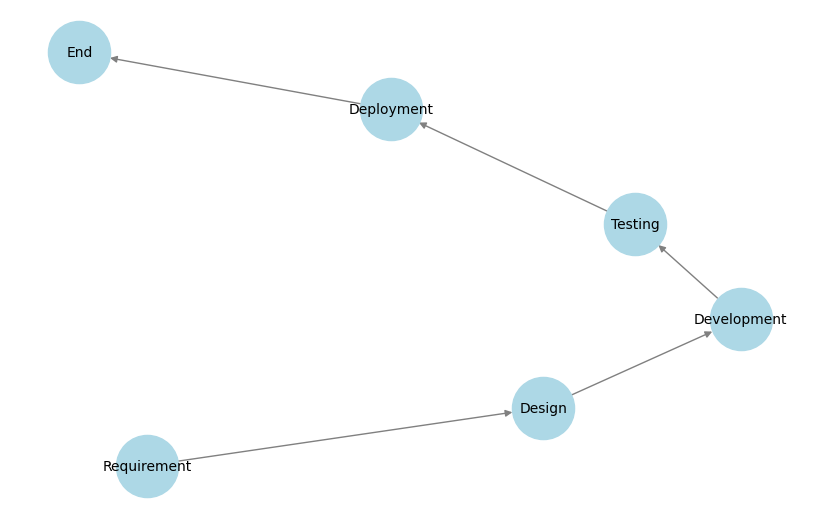

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Define nodes
nodes = ["Requirement", "Design", "Development", "Testing", "Deployment", "End"]
G.add_nodes_from(nodes)

# Define edges (connections)
edges = [("Requirement", "Design"),
         ("Design", "Development"),
         ("Development", "Testing"),
         ("Testing", "Deployment"),
         ("Deployment", "End")]

G.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G)  # Position nodes for visualization
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=10)
plt.show()


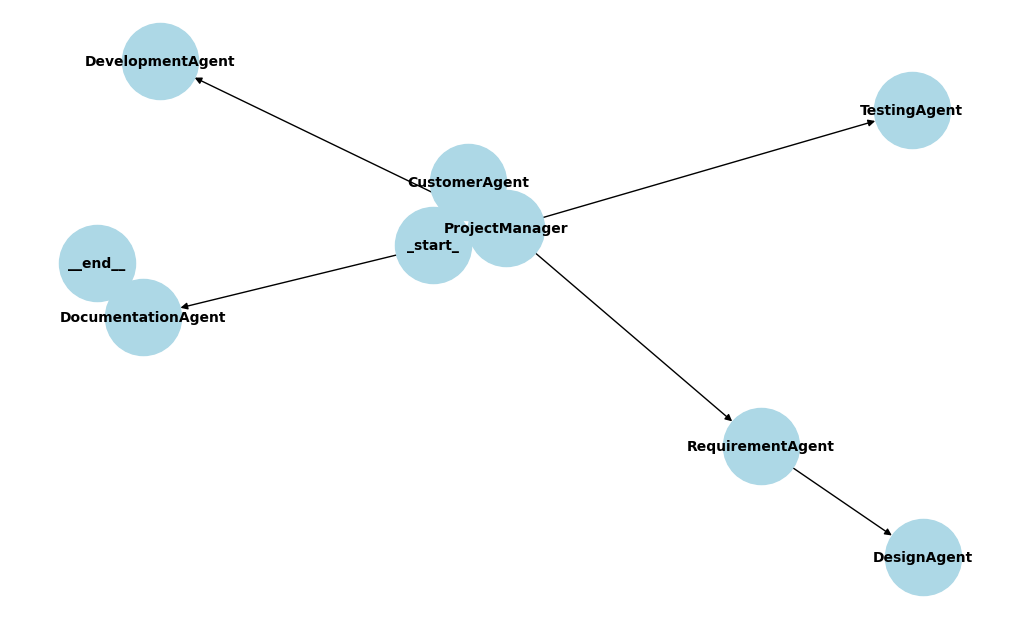

In [80]:
# import networkx as nx
# import matplotlib.pyplot as plt

# # Create a directed graph
# G = nx.DiGraph()

# # Define nodes (agents)
# nodes = [
#     "_start_", "CustomerAgent", "ProjectManager", 
#     "DevelopmentAgent", "TestingAgent", "RequirementAgent", 
#     "DesignAgent", "DocumentationAgent", "__end__"
# ]
# G.add_nodes_from(nodes)

# # Define edges (connections similar to the first image)
# edges = [
#     ("_start_", "CustomerAgent"),
#     ("CustomerAgent", "ProjectManager"),
#     ("ProjectManager", "DevelopmentAgent"),
#     ("ProjectManager", "TestingAgent"),
#     ("ProjectManager", "RequirementAgent"),
#     ("ProjectManager", "DocumentationAgent"),
#     ("RequirementAgent", "DesignAgent"),
#     ("DocumentationAgent", "__end__")
# ]

# G.add_edges_from(edges)

# # Draw the graph
# plt.figure(figsize=(10, 6))
# pos = nx.spring_layout(G, seed=42)  # Seed for consistent layout
# nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="black", node_size=3000, font_size=10, font_weight="bold", arrows=True)

# plt.show()


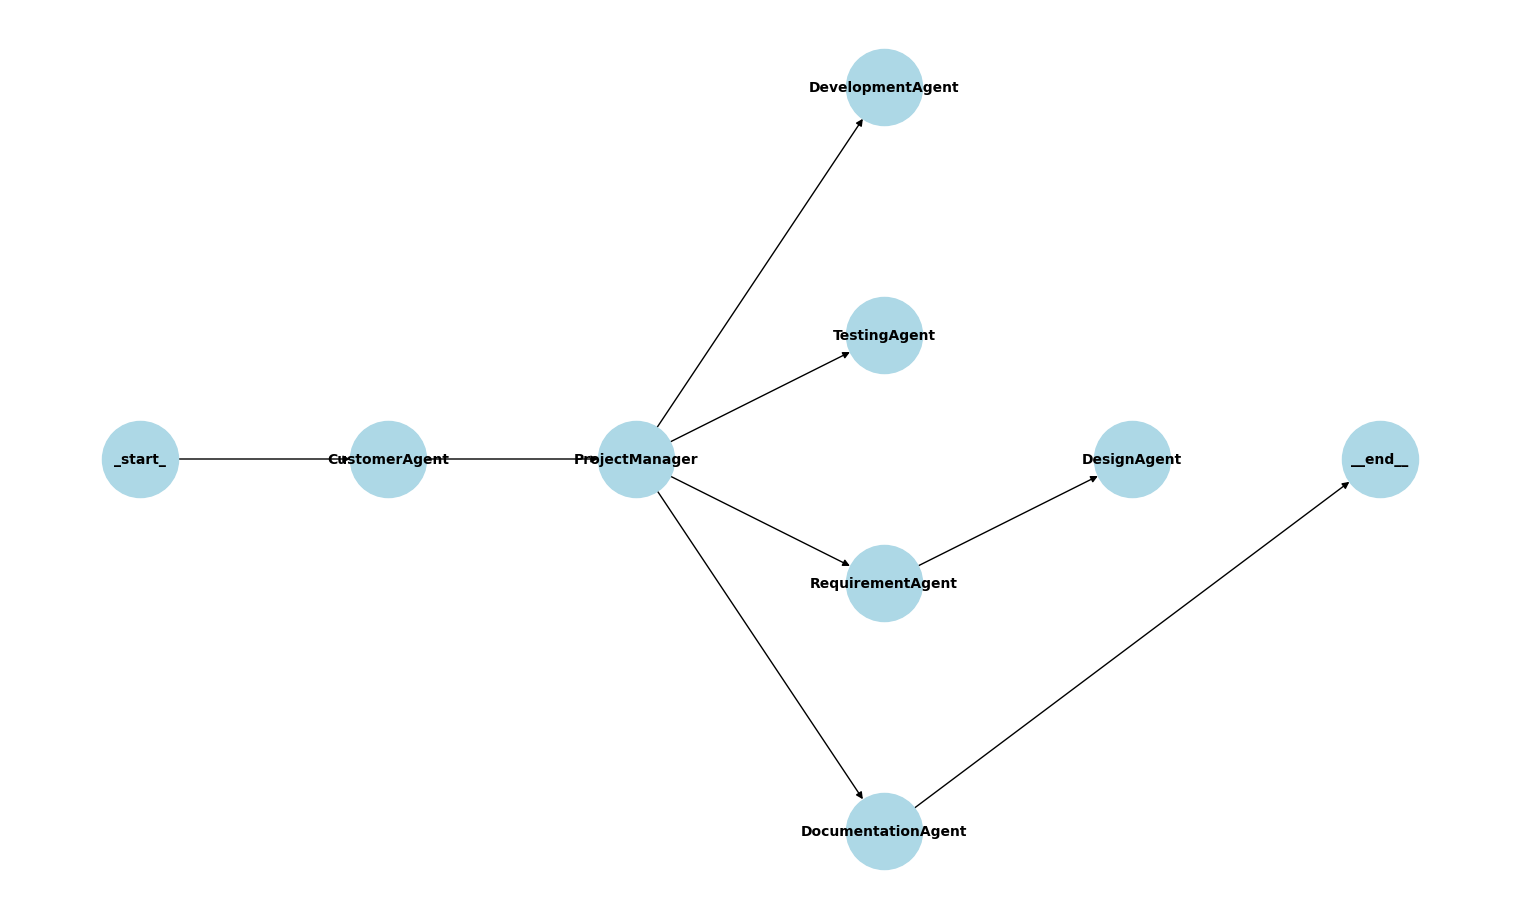

In [94]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Define nodes (agents) and assign hierarchy levels using the "subset" attribute
node_levels = {
    "_start_": 0, "CustomerAgent": 1, "ProjectManager": 2, 
    "DevelopmentAgent": 3, "TestingAgent": 3, "RequirementAgent": 3, 
    "DesignAgent": 4, "DocumentationAgent": 3, "__end__": 5
}

# Add nodes with subset attributes
for node, level in node_levels.items():
    G.add_node(node, subset=level)

# Define edges (connections similar to the first image)
edges = [
    ("_start_", "CustomerAgent"),
    ("CustomerAgent", "ProjectManager"),
    ("ProjectManager", "DevelopmentAgent"),
    ("ProjectManager", "TestingAgent"),
    ("ProjectManager", "RequirementAgent"),
    ("ProjectManager", "DocumentationAgent"),
    ("RequirementAgent", "DesignAgent"),
    ("DocumentationAgent", "__end__")
]
G.add_edges_from(edges)

# Use multipartite layout for hierarchy
plt.figure(figsize=(15, 9))
pos = nx.multipartite_layout(G, subset_key="subset")  # Enforce hierarchy
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="black", node_size=3000, font_size=10, font_weight="bold", arrows=True)

plt.show()


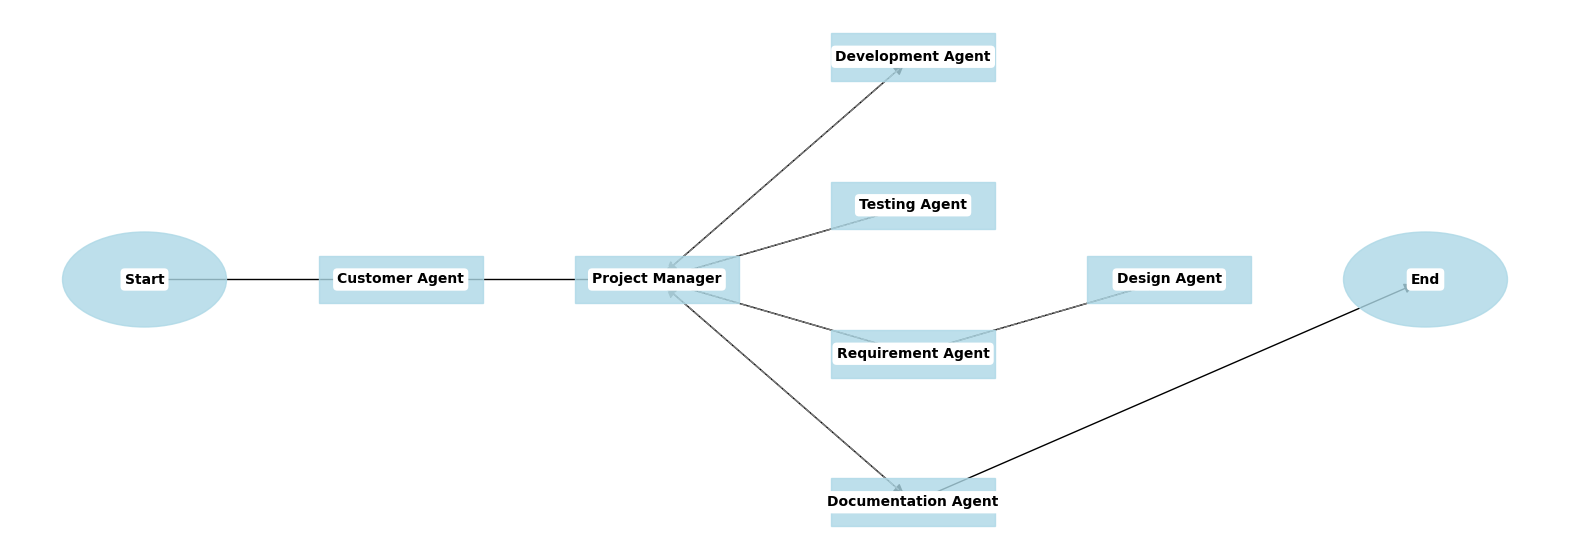

In [112]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Define nodes with hierarchy levels and shapes
nodes = {
    "_start_": {"label": "Start", "level": 0, "shape": "oval"},
    "CustomerAgent": {"label": "Customer Agent", "level": 1, "shape": "rect"},
    "ProjectManager": {"label": "Project Manager", "level": 2, "shape": "rect"},
    "DevelopmentAgent": {"label": "Development Agent", "level": 3, "shape": "rect"},
    "TestingAgent": {"label": "Testing Agent", "level": 3, "shape": "rect"},
    "RequirementAgent": {"label": "Requirement Agent", "level": 3, "shape": "rect"},
    "DesignAgent": {"label": "Design Agent", "level": 4, "shape": "rect"},
    "DocumentationAgent": {"label": "Documentation Agent", "level": 3, "shape": "rect"},
    "__end__": {"label": "End", "level": 5, "shape": "oval"},
}

# Add nodes to the graph with attributes
for node, attr in nodes.items():
    G.add_node(node, label=attr["label"], subset=attr["level"], shape=attr["shape"])

# Define normal workflow edges
edges = [
    ("_start_", "CustomerAgent"),
    ("CustomerAgent", "ProjectManager"),
    ("ProjectManager", "DevelopmentAgent"),
    ("ProjectManager", "TestingAgent"),
    ("ProjectManager", "RequirementAgent"),
    ("ProjectManager", "DocumentationAgent"),
    ("RequirementAgent", "DesignAgent"),
    ("DocumentationAgent", "__end__")
]

# Define feedback (rechecking) edges back to ProjectManager
feedback_edges = [
    ("DevelopmentAgent", "ProjectManager"),
    ("TestingAgent", "ProjectManager"),
    ("RequirementAgent", "ProjectManager"),
    ("DesignAgent", "RequirementAgent"),
    ("DocumentationAgent", "ProjectManager")
]

# Add edges to the graph
G.add_edges_from(edges)
G.add_edges_from(feedback_edges)

# Generate hierarchical layout based on subset levels
pos = nx.multipartite_layout(G, subset_key="subset")

# Draw figure
plt.figure(figsize=(20, 7))

# Draw normal edges (solid)
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="black", arrows=True, arrowstyle="-|>", arrowsize=15)

# Draw feedback edges (dashed)
nx.draw_networkx_edges(G, pos, edgelist=feedback_edges, edge_color="gray", style="dashed", arrows=True, arrowstyle="-|>", arrowsize=15)

# Draw nodes with specific shapes and text inside
for node, (x, y) in pos.items():
    shape = nodes[node]["shape"]
    if shape == "oval":
        ellipse = plt.Circle((x, y), 0.12, color="lightblue", alpha=0.8)
        plt.gca().add_patch(ellipse)
        plt.text(x, y, nodes[node]["label"], ha="center", va="center", fontsize=10, fontweight="bold", bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
    else:
        plt.gca().add_patch(plt.Rectangle((x - 0.12, y - 0.06), 0.24, 0.12, color="lightblue", alpha=0.8))
        plt.text(x, y, nodes[node]["label"], ha="center", va="center", fontsize=10, fontweight="bold", bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

# Remove axis
plt.axis("off")

# Show plot
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_14480\410221962.py:76: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ellipse = plt.Circle((x, y), 0.15, color="lightblue", alpha=0.8, lw=2, edgecolor="black")
C:\Users\HP\AppData\Local\Temp\ipykernel_14480\410221962.py:79: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((x - 0.15, y - 0.08), 0.3, 0.16, color="lightblue", alpha=0.8, lw=2, edgecolor="black")


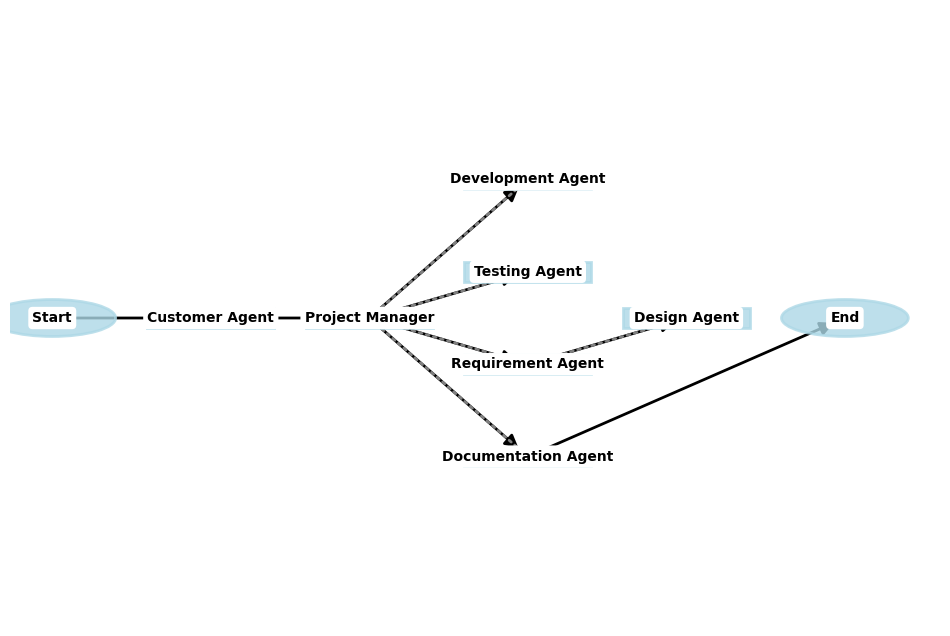

In [114]:
# Enhancing spacing and arrow visibility

import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as patches

# Create a directed graph
G = nx.DiGraph()

# Define nodes with hierarchy levels and shapes
nodes = {
    "_start_": {"label": "Start", "level": 0, "shape": "oval"},
    "CustomerAgent": {"label": "Customer Agent", "level": 1, "shape": "rect"},
    "ProjectManager": {"label": "Project Manager", "level": 2, "shape": "rect"},
    "DevelopmentAgent": {"label": "Development Agent", "level": 3, "shape": "rect"},
    "TestingAgent": {"label": "Testing Agent", "level": 3, "shape": "rect"},
    "RequirementAgent": {"label": "Requirement Agent", "level": 3, "shape": "rect"},
    "DesignAgent": {"label": "Design Agent", "level": 4, "shape": "rect"},
    "DocumentationAgent": {"label": "Documentation Agent", "level": 3, "shape": "rect"},
    "__end__": {"label": "End", "level": 5, "shape": "oval"},
}

# Add nodes to the graph with attributes
for node, attr in nodes.items():
    G.add_node(node, label=attr["label"], subset=attr["level"], shape=attr["shape"])

# Define normal workflow edges
edges = [
    ("_start_", "CustomerAgent"),
    ("CustomerAgent", "ProjectManager"),
    ("ProjectManager", "DevelopmentAgent"),
    ("ProjectManager", "TestingAgent"),
    ("ProjectManager", "RequirementAgent"),
    ("ProjectManager", "DocumentationAgent"),
    ("RequirementAgent", "DesignAgent"),
    ("DocumentationAgent", "__end__")
]

# Define feedback (rechecking) edges back to ProjectManager
feedback_edges = [
    ("DevelopmentAgent", "ProjectManager"),
    ("TestingAgent", "ProjectManager"),
    ("RequirementAgent", "ProjectManager"),
    ("DesignAgent", "RequirementAgent"),
    ("DocumentationAgent", "ProjectManager")
]

# Add edges to the graph
G.add_edges_from(edges)
G.add_edges_from(feedback_edges)

# Generate hierarchical layout with better spacing
pos = nx.multipartite_layout(G, subset_key="subset")

# Adjust positions to give better spacing
for key in pos:
    pos[key][1] *= 2  # Expanding vertical spacing

# Draw figure with proper initialization
fig, ax = plt.subplots(figsize=(12, 8))

# Draw normal edges (solid, bold arrows)
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="black", width=2, arrows=True, arrowstyle="-|>", arrowsize=20, ax=ax)

# Draw feedback edges (dotted curved style, bold)
for edge in feedback_edges:
    start, end = edge
    con = patches.ConnectionPatch(pos[start], pos[end], "data", "data", arrowstyle="-|>", linestyle="dotted",
                                  linewidth=2, edgecolor="gray", axes=ax)
    ax.add_patch(con)

# Draw nodes with specific shapes and text inside
for node, (x, y) in pos.items():
    shape = nodes[node]["shape"]
    if shape == "oval":
        ellipse = plt.Circle((x, y), 0.15, color="lightblue", alpha=0.8, lw=2, edgecolor="black")
        ax.add_patch(ellipse)
    else:
        rect = plt.Rectangle((x - 0.15, y - 0.08), 0.3, 0.16, color="lightblue", alpha=0.8, lw=2, edgecolor="black")
        ax.add_patch(rect)

    ax.text(x, y, nodes[node]["label"], ha="center", va="center", fontsize=10, fontweight="bold",
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

# Remove axis
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-2.5, 2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Show plot
plt.show()
